In [63]:
import pandas as pd

In [111]:
import matplotlib.pyplot as plt

In [112]:
import os
print(os.getcwd())

C:\Users\muham


In [114]:
df =pd.read_csv("ecommerce_sales_data.csv")

In [115]:
df.shape

(3500, 8)

In [116]:
df.info

<bound method DataFrame.info of       Order Date Product Name     Category Region  Price  Quantity  Sales  \
0     2024-12-31      Printer       Office  North   3200         4   3640   
1     2022-11-27        Mouse  Accessories   East   3210         7   1197   
2     2022-05-11       Tablet  Electronics  South    321         5   5865   
3     2024-03-16        Mouse  Accessories  South     56         2    786   
4     2022-09-10        Mouse  Accessories   West    908         1    509   
...          ...          ...          ...    ...    ...       ...    ...   
3495  2023-02-15      Monitor  Accessories  North   3797         4   4064   
3496  2022-09-18      Monitor  Accessories   East   3798         1   1117   
3497  2022-04-12       Laptop  Electronics  South   3799         4    260   
3498  2022-01-18      Printer       Office  South   3800         3    222   
3499  2024-11-01   Smartwatch  Electronics   East   3801         9  10530   

       Profit  
0      348.93  
1      106.

In [117]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Price           0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [118]:
df.duplicated().sum()

np.int64(0)

In [119]:
# fix data tyoes

In [120]:
df["Order Date"]=pd.to_datetime(df["Order Date"])

In [121]:
# total sales

In [122]:
df["Total Sale"]=df["Price"]*df["Quantity"]

In [123]:
df

,Order Date,Product Name,Category,Region,Price,Quantity,Sales,Profit,Total Sale
0,2024-12-31,Printer,Office,North,3200,4,3640,348.93,12800
1,2022-11-27,Mouse,Accessories,East,3210,7,1197,106.53,22470
2,2022-05-11,Tablet,Electronics,South,321,5,5865,502.73,1605
3,2024-03-16,Mouse,Accessories,South,56,2,786,202.87,112
4,2022-09-10,Mouse,Accessories,West,908,1,509,103.28,908
...,...,...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,3797,4,4064,771.16,15188
3496,2022-09-18,Monitor,Accessories,East,3798,1,1117,119.89,3798
3497,2022-04-12,Laptop,Electronics,South,3799,4,260,66.02,15196
3498,2022-01-18,Printer,Office,South,3800,3,222,50.28,11400


In [124]:
df["Total Sale"].sum()

np.int64(35678639)

In [125]:
# top selling product 

In [126]:
df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: Sales, dtype: int64

In [127]:
# category wise sale

In [128]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Electronics    5326074
Accessories    4247591
Office         1094216
Name: Sales, dtype: int64

In [129]:
df["Month"]= df["Order Date"].dt.month

In [130]:
# monthly sale

In [131]:
df.groupby("Month")["Total Sale"].sum()

Month
1     3113028
2     2443839
3     3298226
4     2825159
5     3072620
6     3024166
7     2819644
8     2996689
9     2839754
10    3083164
11    3053346
12    3109004
Name: Total Sale, dtype: int64

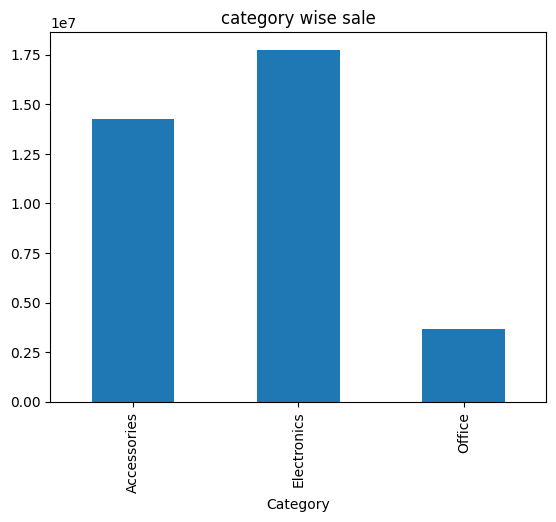

In [132]:
df.groupby("Category")["Total Sale"].sum().plot(kind="bar")
plt.title("category wise sale")
plt.show()

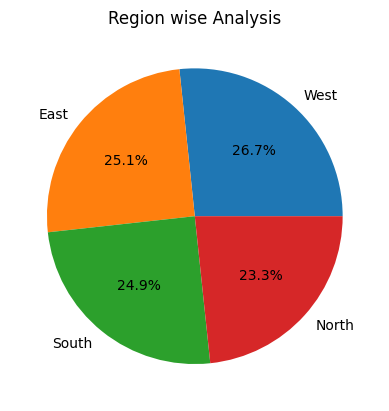

In [133]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False).plot(kind="pie",autopct='%1.1f%%')
plt.title("Region wise Analysis")
plt.show()

In [134]:
df["Day wise Sale"]=df["Order Date"].dt.day

In [135]:
df

,Order Date,Product Name,Category,Region,Price,Quantity,Sales,Profit,Total Sale,Month,Day wise Sale
0,2024-12-31,Printer,Office,North,3200,4,3640,348.93,12800,12,31
1,2022-11-27,Mouse,Accessories,East,3210,7,1197,106.53,22470,11,27
2,2022-05-11,Tablet,Electronics,South,321,5,5865,502.73,1605,5,11
3,2024-03-16,Mouse,Accessories,South,56,2,786,202.87,112,3,16
4,2022-09-10,Mouse,Accessories,West,908,1,509,103.28,908,9,10
...,...,...,...,...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,3797,4,4064,771.16,15188,2,15
3496,2022-09-18,Monitor,Accessories,East,3798,1,1117,119.89,3798,9,18
3497,2022-04-12,Laptop,Electronics,South,3799,4,260,66.02,15196,4,12
3498,2022-01-18,Printer,Office,South,3800,3,222,50.28,11400,1,18


In [136]:
df.groupby("Day wise Sale")["Sales"].sum()

Day wise Sale
1     412480
2     327699
3     324141
4     394878
5     369101
6     311538
7     330726
8     292114
9     325177
10    356975
11    366816
12    319485
13    437183
14    367157
15    340833
16    378094
17    390072
18    391590
19    363121
20    369413
21    393886
22    275854
23    298956
24    422687
25    352053
26    309037
27    268697
28    318871
29    369531
30    269117
31    220599
Name: Sales, dtype: int64